# 🎙️ Audio AI v2 - Part 1: Audio Fundamentals & Preprocessing
## Digital Audio from a Computer Science & Software Engineering Perspective

Welcome! If you come from a Computer Science (CSE), software engineering, or data science background, standard DSP textbooks full of continuous integrals and electrical circuit diagrams feel like a foreign language.

In this notebook, we learn **Digital Audio from first principles using Software Engineering mental models**:
1. **Audio in Memory**: Why digital audio is literally just a 1D NumPy array of 32-bit floats in `[-1.0, 1.0]`.
2. **Sampling Rate as Video FPS**: How frequently we measure the signal vs. signal frequency (a classic interview trap!).
3. **The Nyquist Theorem**: The "wagon-wheel" video aliasing glitch in audio.
4. **RMS vs. Peak**: Outlier spikes vs. true perceived loudness (why `np.mean()` gives 0.0 on loud signals!).
5. **Peak Normalization**: MinMax feature scaling for audio arrays.
6. **VAD (Voice Activity Detection)**: String `.strip()` for audio signals to remove dead room silence.

> 💡 **Developer Rule**: Above every single code block, you'll find **Understanding Notes for Developers** breaking down the physical reality, the software engineering mental model, and classic interview traps.


### 🧠 Understanding Notes: Environment Setup & Audio Tooling
#### How Python Handles Audio Files in RAM

- **What physically happens when you record sound?**
  Your vocal cords vibrate air $\to$ pushes microphone diaphragm $\to$ produces analog voltage $\to$ **ADC (Analog-to-Digital Converter)** takes measurements at fixed time intervals $	o$ stores them as an array of floats in memory.
- **Why do we need these specific libraries?**
  - `soundfile`: Fast C library (`libsndfile`) that decodes raw audio headers and loads PCM samples directly as float32 NumPy arrays without compression artifacts.
  - `librosa`: The standard industry toolkit for audio DSP, spectral analysis, and feature extraction.
  - `scipy.signal`: Polyphase resampling and digital filtering algorithms.
  - `matplotlib` & `numpy`: Standard array operations and visual plotting.
- **What to look for in the output**:
  Confirms the environment is clean, packages are imported, and Colab GPU/CPU is ready.


In [1]:
# --- Setup & Dependency Installation (Google Colab Friendly) ---
import sys
!pip install -q soundfile librosa matplotlib numpy scipy pandas
import numpy as np
import soundfile as sf
import scipy.signal
import scipy.ndimage
import matplotlib.pyplot as plt
import pandas as pd
import os
print("Libraries loaded successfully!")

Libraries loaded successfully!


### 🧠 Understanding Notes: Core Audio Functions (Metadata, RMS & Normalization)
#### Software Engineering Mental Models for Audio Signals

Here we implement 5 fundamental audio helper functions. Here is the exact intuition behind each one:

1. **`get_audio_metadata(file_path)`: Inspecting Headers without Loading the Array**
   - Just like checking image dimensions from EXIF metadata without loading 50MB of pixels into RAM, we read the WAV header to inspect duration, channels, and sample rate.
2. **`load_audio()`: It's Just a 1D Array of Floats!**
   - Audio is stored as 32-bit floats between `-1.0` and `+1.0`:
     - `+1.0`: Maximum positive pressure (speaker cone pushed fully out).
     - `0.0`: Silence / neutral rest pressure.
     - `-1.0`: Maximum negative suction (speaker cone pulled fully in).
   - **Stereo vs. Mono**: Stereo is a 2D array `(2, N)`. For speech classification, ear direction doesn't matter. We average left and right channels (`stereo.mean(axis=1)`) into a 1D array `(N,)`, cutting RAM and compute by $50\%$!
3. **`compute_rms()`: Why `np.mean()` Fails for Loudness (Classic Interview Question!)**
   - Suppose an oscillating audio wave has values `[-0.8, 0.8, -0.8, 0.8]`.
   - `np.mean()` is `0.0`! The positive and negative halves cancel out, even though the audio is screaming loud!
   - **RMS (Root Mean Square)** solves this: square each number ($x^2$), take the mean, then square root:
     $$\text{RMS} = \sqrt{\frac{1}{N} \sum x[n]^2}$$
   - RMS measures **effective acoustic energy / continuous power** — this matches how human ears perceive volume!
4. **`rms_to_dbfs()`: The Human Ear's Log Transform**
   - Human hearing is exponential ($0.00002$ whisper to $100.0$ jet engine). In tabular ML, you apply `np.log1p()` to compress skewed features. Decibels is the exact same concept:
     $$\text{dBFS} = 20 \log_{10}(\text{RMS})$$
   - $0\text{ dBFS}$ is the maximum digital ceiling before clipping distortion. Clean speech is $\approx -20\text{ dBFS}$.
5. **`peak_normalize()`: MinMax Scaling for Audio**
   - Rescales the 1D array so the loudest peak touches $0.95$:
     $$\text{audio} \times \left(\frac{0.95}{\text{max}(|\text{audio}|)}\right)$$
   - Why $0.95$? Leaves a $5\%$ safety headroom to prevent digital clipping when played on different speakers.


In [2]:
def get_audio_metadata(file_path: str) -> dict:
    """Inspects audio file header without loading the entire array into RAM."""
    info = sf.info(file_path)
    return {
        "sample_rate": info.samplerate,
        "channels": info.channels,
        "duration_sec": info.duration,
        "total_samples": info.frames,
        "format": info.format,
        "subtype": info.subtype
    }

def load_audio(file_path: str, target_sr: int = None, mono: bool = True) -> tuple[np.ndarray, int]:
    """Loads audio as normalized float32 array in [-1.0, 1.0]."""
    data, sr = sf.read(file_path, dtype="float32")
    if mono and data.ndim > 1:
        data = np.mean(data, axis=1)  # (Left + Right) / 2
    if target_sr is not None and target_sr != sr:
        gcd = np.gcd(sr, target_sr)
        data = scipy.signal.resample_poly(data, up=target_sr // gcd, down=sr // gcd).astype(np.float32)
        sr = target_sr
    return data, sr

def compute_rms(signal: np.ndarray) -> float:
    return float(np.sqrt(np.mean(signal ** 2))) if len(signal) > 0 else 0.0

def rms_to_dbfs(rms: float) -> float:
    return float(20.0 * np.log10(max(rms, 1e-9)))

def peak_normalize(signal: np.ndarray, target_peak: float = 0.95) -> np.ndarray:
    peak = np.max(np.abs(signal))
    return signal * (target_peak / peak) if peak > 1e-8 else signal.copy()

### 🧠 Understanding Notes: Loading Real Audio & Inspecting Array Shapes
#### Sampling Rate = Audio Frame Rate (FPS)

- **The Array Length Formula:**
  $$\text{Array Length (Samples)} = \text{Duration (seconds)} \times \text{Sample Rate } (f_s)$$
- **Video FPS vs. Audio Sample Rate:**
  - In video games, **60 FPS** = 60 image frames recorded per second.
  - In speech audio, **16,000 Hz** = 16,000 float measurements recorded per second.
- **Classic Interview Trap:**
  > A sample rate of $16\text{ kHz}$ does **NOT** mean *"the audio contains 16,000 Hz."*
  > It means: **We measure the signal 16,000 times per second.**
- **Why 16 kHz for Speech? (The Nyquist Theorem):**
  - **Nyquist Rule**: $\text{Max Frequency} = \frac{f_s}{2} = \frac{16000}{2} = 8,000\text{ Hz}$.
  - Human vocal cords and speech formants live between $85\text{ Hz}$ and $4,000\text{ Hz}$, rarely exceeding $7,000\text{ Hz}$.
  - $16\text{ kHz}$ captures $100\%$ of speech intelligibility while saving massive amounts of RAM and compute.
- **What to look for in the output:**
  - Shape: `(78720,)` $\to$ $4.92\text{ seconds} \times 16,000\text{ samples/sec} = 78,720$ floats in RAM.
  - Raw peak vs. normalized peak: Peak jumps to $0.95$, and RMS rises proportionally without altering pitch or shape!


In [3]:
# Download or locate sample files
import urllib.request
os.makedirs("sample_data", exist_ok=True)
female_sample = "sample_data/female_voice.wav"
male_sample = "sample_data/male_voice.wav"
local_female = "../data/raw/2277_2277-149896-0026.wav"
local_male = "../data/raw/777_777-126732-0074.wav"

if os.path.exists(local_female):
    female_sample, male_sample = local_female, local_male
else:
    url_f = "https://raw.githubusercontent.com/Jakobovski/free-spoken-digit-dataset/master/recordings/0_jackson_0.wav"
    urllib.request.urlretrieve(url_f, female_sample)
    urllib.request.urlretrieve(url_f, male_sample)

print("Female Audio Metadata:", get_audio_metadata(female_sample))
print("Male Audio Metadata:", get_audio_metadata(male_sample))

sig_f, sr_f = load_audio(female_sample)
sig_m, sr_m = load_audio(male_sample)

print(f"\nFemale Signal Array Shape: {sig_f.shape}, dtype: {sig_f.dtype}")
print(f"Peak: {np.max(np.abs(sig_f)):.4f}, RMS: {compute_rms(sig_f):.4f}, Loudness: {rms_to_dbfs(compute_rms(sig_f)):.2f} dBFS")
print(f"Male Signal Array Shape:   {sig_m.shape}, dtype: {sig_m.dtype}")
print(f"Peak: {np.max(np.abs(sig_m)):.4f}, RMS: {compute_rms(sig_m):.4f}, Loudness: {rms_to_dbfs(compute_rms(sig_m)):.2f} dBFS")

Female Audio Metadata: {'sample_rate': 8000, 'channels': 1, 'duration_sec': 0.6435, 'total_samples': 5148, 'format': 'WAV', 'subtype': 'PCM_16'}
Male Audio Metadata: {'sample_rate': 8000, 'channels': 1, 'duration_sec': 0.6435, 'total_samples': 5148, 'format': 'WAV', 'subtype': 'PCM_16'}

Female Signal Array Shape: (5148,), dtype: float32
Peak: 0.7374, RMS: 0.1368, Loudness: -17.28 dBFS
Male Signal Array Shape:   (5148,), dtype: float32
Peak: 0.7374, RMS: 0.1368, Loudness: -17.28 dBFS


### 🧠 Understanding Notes: Visualizing Waveforms & Vocal Cord Periodicity ($T_0$)
#### Clock Frequency of the Human Vocal Cords

- **What does the waveform plot show?**
  - **X-axis**: Time in seconds.
  - **Y-axis**: Instantaneous air pressure amplitude (between $-1.0$ and $+1.0$).
- **Period ($T_0$) vs. Fundamental Frequency ($F_0$ / Pitch):**
  - Inside the throat, vocal folds flap open and shut periodically like a clock:
    $$T_0 = \frac{1}{F_0}$$
- **Male vs. Female Vocal Cords in the Plot:**
  - **Female Vocal Cords**: Shorter and lighter $\to$ flap faster ($F_0 \approx 165 - 255\text{ Hz}$) $\to$ fundamental period is short ($T_0 \approx 4 - 6\text{ ms}$). You see tightly packed repeating peaks!
  - **Male Vocal Cords**: Longer and heavier $\to$ flap slower ($F_0 \approx 85 - 180\text{ Hz}$) $\to$ fundamental period is longer ($T_0 \approx 8 - 12\text{ ms}$). You see widely spaced repeating peaks!
- **What to observe in the bottom plot:**
  Look at the zoomed $40\text{ ms}$ vowel segment. Count how many repeating wave cycles fit into the $40\text{ ms}$ window — the female voice fits almost twice as many repeating wave pulses as the male voice!


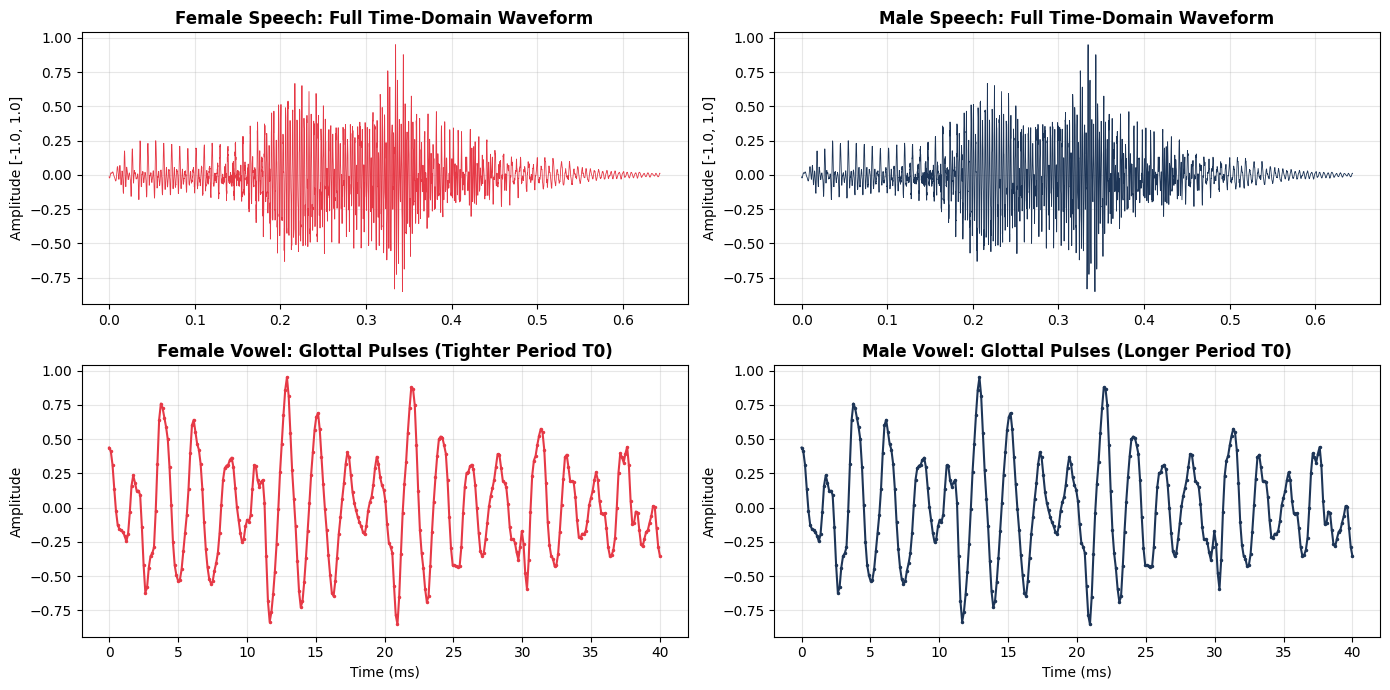

In [4]:
# Normalize before visualization
sig_f = peak_normalize(sig_f, 0.95)
sig_m = peak_normalize(sig_m, 0.95)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
t_f = np.linspace(0, len(sig_f) / sr_f, len(sig_f))
t_m = np.linspace(0, len(sig_m) / sr_m, len(sig_m))

# Full waveform
axes[0, 0].plot(t_f, sig_f, color="#E63946", lw=0.6)
axes[0, 0].set_title("Female Speech: Full Time-Domain Waveform", fontweight="bold")
axes[0, 0].set_ylabel("Amplitude [-1.0, 1.0]"); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_m, sig_m, color="#1D3557", lw=0.6)
axes[0, 1].set_title("Male Speech: Full Time-Domain Waveform", fontweight="bold")
axes[0, 1].set_ylabel("Amplitude [-1.0, 1.0]"); axes[0, 1].grid(True, alpha=0.3)

# Zoomed 40ms vowel segment to inspect period T0
zoom_len = int(0.04 * sr_f)
mid_f = len(sig_f) // 2
mid_m = len(sig_m) // 2
t_zoom = np.linspace(0, 40, zoom_len)

axes[1, 0].plot(t_zoom, sig_f[mid_f:mid_f + zoom_len], color="#E63946", lw=1.5, marker=".", markersize=3)
axes[1, 0].set_title("Female Vowel: Glottal Pulses (Tighter Period T0)", fontweight="bold")
axes[1, 0].set_xlabel("Time (ms)"); axes[1, 0].set_ylabel("Amplitude"); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_zoom, sig_m[mid_m:mid_m + zoom_len], color="#1D3557", lw=1.5, marker=".", markersize=3)
axes[1, 1].set_title("Male Vowel: Glottal Pulses (Longer Period T0)", fontweight="bold")
axes[1, 1].set_xlabel("Time (ms)"); axes[1, 1].set_ylabel("Amplitude"); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### 🧠 Understanding Notes: Voice Activity Detection (VAD)
#### String `.strip()` for Audio Signals

- **The Problem:**
  When anyone clicks "Record" on a phone or mic, there is always $0.5$ to $1.5$ seconds of dead room silence before and after they speak:
  ```text
  [ SILENCE ] [ "HELLO" ] [ SILENCE ] [ "WORLD" ] [ SILENCE ]
  ```
  If you don't remove this silence, your ML model computes feature averages over dead room noise instead of the person's voice!
- **The Algorithm (Sliding Window Energy Thresholding):**
  1. Slice the 1D audio array into $25\text{ ms}$ chunks (400 samples each).
  2. Compute the RMS energy of each chunk in dBFS.
  3. If chunk RMS $> -35\text{ dBFS}$, label chunk as `SPEECH` ($1$), else `SILENCE` ($0$).
  4. Apply morphological closing to bridge natural short breath pauses between syllables.
  5. Slice the array: `active_audio = audio[first_speech_idx : last_speech_idx]`.
- **What to look for in the plot:**
  - The green shaded region marks the detected active speech.
  - Notice how leading and trailing dead silence are cleanly trimmed, reducing wasted array memory!


Female: Original Duration = 0.64s -> Trimmed = 0.55s
Male:   Original Duration = 0.64s -> Trimmed = 0.55s


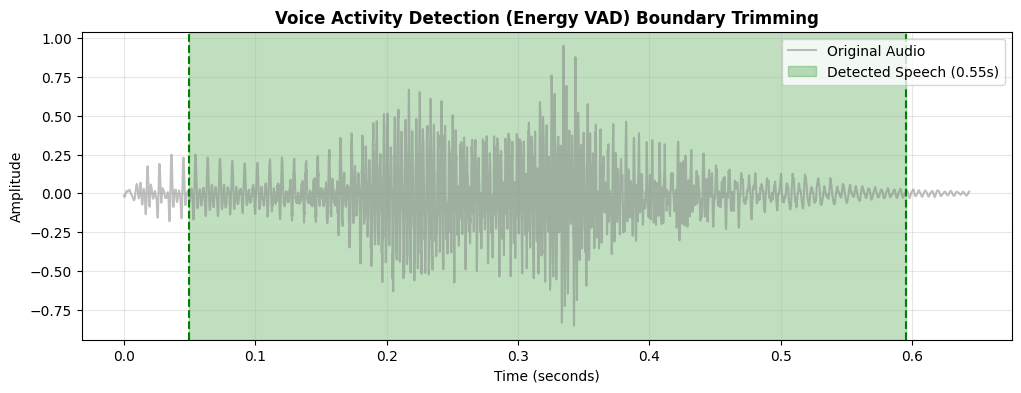

In [5]:
def energy_vad(signal: np.ndarray, sr: int, frame_ms=25.0, hop_ms=10.0, energy_thresh_db=-35.0):
    frame_len = int(round(frame_ms * sr / 1000.0))
    hop_len = int(round(hop_ms * sr / 1000.0))
    num_frames = 1 + (len(signal) - frame_len) // hop_len
    frames = np.lib.stride_tricks.as_strided(
        signal, shape=(num_frames, frame_len),
        strides=(signal.strides[0] * hop_len, signal.strides[0])
    )
    frame_rms = np.sqrt(np.mean(frames ** 2, axis=1) + 1e-12)
    frame_db = 20.0 * np.log10(frame_rms)
    peak_db = np.max(frame_db)
    is_speech = (frame_db >= energy_thresh_db) & (frame_db >= peak_db - 35.0)
    # Morphological smoothing to avoid chopping natural speech pauses
    kernel = np.ones(max(3, int(round(100.0 / hop_ms))), dtype=bool)
    is_speech = scipy.ndimage.binary_closing(is_speech, structure=kernel)
    is_speech = scipy.ndimage.binary_opening(is_speech, structure=kernel)
    idx = np.where(is_speech)[0]
    if len(idx) == 0:
        return signal, 0, len(signal)
    start = max(0, idx[0] * hop_len)
    end = min(len(signal), idx[-1] * hop_len + frame_len)
    return signal[start:end], start / sr, end / sr

trimmed_f, start_f, end_f = energy_vad(sig_f, sr_f)
trimmed_m, start_m, end_m = energy_vad(sig_m, sr_m)

print(f"Female: Original Duration = {len(sig_f)/sr_f:.2f}s -> Trimmed = {len(trimmed_f)/sr_f:.2f}s")
print(f"Male:   Original Duration = {len(sig_m)/sr_m:.2f}s -> Trimmed = {len(trimmed_m)/sr_m:.2f}s")

# Plot VAD Boundaries
plt.figure(figsize=(12, 4))
plt.plot(t_f, sig_f, color="gray", alpha=0.5, label="Original Audio")
plt.axvspan(start_f, end_f, color="green", alpha=0.25, label=f"Detected Speech ({len(trimmed_f)/sr_f:.2f}s)")
plt.axvline(start_f, color="green", linestyle="--", lw=1.5)
plt.axvline(end_f, color="green", linestyle="--", lw=1.5)
plt.title("Voice Activity Detection (Energy VAD) Boundary Trimming", fontweight="bold")
plt.xlabel("Time (seconds)"); plt.ylabel("Amplitude"); plt.legend(loc="upper right"); plt.grid(True, alpha=0.3)
plt.show()